# Uses 'Kaggle_TicTacToe.csv', 'full_player1_results.csv', and 'partial_player1_results.csv'
data from https://www.kaggle.com/datasets/fabdelja/tictactoe?resource=download

In [20]:
import pandas as pd
import numpy as np

# read in the dataset and change the 'Class' column to 'Outcome'
df = pd.read_csv("Kaggle_TicTacToe.csv") #.head(50)
df1 = df.rename({'CLASS' : 'OUTCOME'}, axis=1)

# dropped these columns because there cannot be more than 5 moves in a game of tic-tac-toe
df2 = df1.drop(['MOVE6', 'MOVE7'], axis=1)

# made the values 1 less than they should be
df3 = df2.replace("win", 0).replace("loss", -2).replace("draw", -1).replace("?", -1) 
df4 = df3.astype(int).add(1)

# split the dataset into two because one line represents the first player, and the next represents the second player
player_one = df4[df4.index % 2 == 0] 
player_two = df4[df4.index % 2 == 1]

# drop all of the rows that do not have a 5 (middle box) as the first move and a 1 (top left box) as the second move
df5 = player_one.drop(player_one[player_one.MOVE1 != 5].index)
df6 = df5.drop(df5[df5.MOVE2 != 1].index)

#df6.shape
df6

,MOVE1,MOVE2,MOVE3,MOVE4,MOVE5,OUTCOME
160,5,1,8,6,3,0
260,5,1,6,8,7,0
364,5,1,6,8,7,0
506,5,1,9,0,0,1
540,5,1,7,0,0,1
...,...,...,...,...,...,...
2236,5,1,9,0,0,-1
2272,5,1,8,2,0,-1
2382,5,1,6,7,8,0
2398,5,1,6,2,7,0


In [21]:
data = df6.values.tolist()
new_list = []
zero_count = 0 

for row in data:
    new_list = [row[0], row[1], row[2], row[3], row[4]]
    zero_count = new_list.count(0)
    row.append(len(row)-1-zero_count)

In [23]:
import csv

header = ['Outcome', 'Decision1', 'Decision2', 'Decision3', 'Decision4', 'Decision5']
final = []

for row in data: 
    final.append([row[-2], int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4])])

with open('partial_player1_results.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(final)

In [ ]:
data2 = player_one.values.tolist()
new_list2 = []

for row2 in data2:
    new_list2 = [row2[0], row2[1], row2[2], row2[3], row2[4]]
    zero_count = new_list.count(0)
    row2.append(len(row2)-1-zero_count)

In [24]:
import csv

header = ['Outcome', 'Decision1', 'Decision2', 'Decision3', 'Decision4', 'Decision5']
final = []

for row in data2: 
    final.append([row[-2], int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4])])

with open('full_player1_results.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(final)

In [22]:
# sort the datasets based on the outcome (win, loss, draw) and the number of decisions made during each game
def sortLast(val):
    return val[-1]
 
def sortSecondtoLast(val):
    return val[-2]

data.sort(key=sortLast,reverse=True)
data.sort(key=sortSecondtoLast,reverse=True)

data2.sort(key=sortLast,reverse=True)
data2.sort(key=sortSecondtoLast,reverse=True)

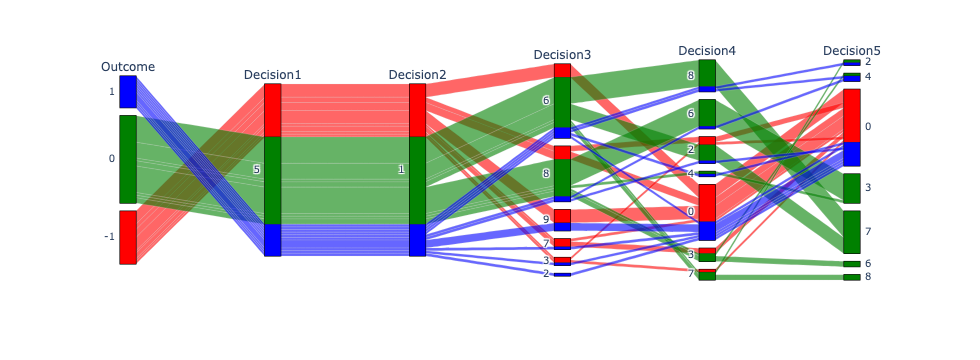

In [25]:
import pandas as pd
import numpy as np
import plotly.express as px

new_data = pd.read_csv("partial_player1_results.csv")
fig = px.parallel_categories(new_data, color = "Outcome", color_continuous_scale=["red", "green", "blue"]) 
fig.update_coloraxes(showscale=False)
fig.show()

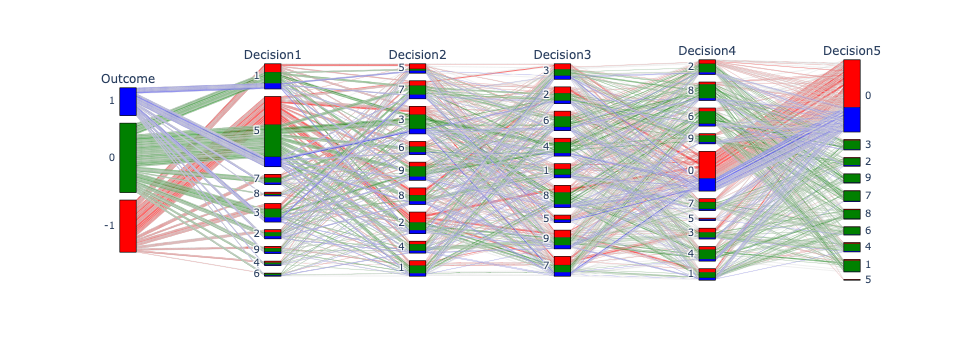

In [26]:
import pandas as pd
import numpy as np
import plotly.express as px

new_data = pd.read_csv("full_player1_results.csv")
fig = px.parallel_categories(new_data, color = "Outcome", color_continuous_scale=["red", "green", "blue"]) 
fig.update_coloraxes(showscale=False)
fig.show()